# MultiHead Sweep Results
Loads all `checkpoints/multihead/*/best.pt` and visualises performance across sweep axes.

Primary metric: **mean cosine similarity** (SigLIP + CLIP heads). Secondary: 2-AFC, per-head breakdown.

In [1]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

SWEEP_AXES = ["loss_weight_t5", "d_model", "n_layers", "shared_dim", "t5_pca_k"]

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location="cpu")
    except Exception as e:
        return None
    row = {**ckpt["args"], **ckpt["metrics"], "path": str(pt)}
    if "test_metrics" in ckpt:
        row.update(ckpt["test_metrics"])
    return row

candidates = sorted((CHECKPOINT_DIR / "multihead").glob("*/best.pt"))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Loading"):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = "test_cos_siglip" in df.columns

for col in SWEEP_AXES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

print(f"{len(df)} runs loaded  |  test metrics present: {has_test}")
print(df[SWEEP_AXES + ["val_mean_cos","val_mean_2afc"]].sort_values("val_mean_cos", ascending=False).to_string(index=False))


Loading:   0%|          | 0/192 [00:00<?, ?it/s]

192 runs loaded  |  test metrics present: True
 loss_weight_t5  d_model  n_layers  shared_dim  t5_pca_k  val_mean_cos  val_mean_2afc
            0.5       64         2         256        64      0.669170       0.512857
            0.5       64         4         256        64      0.668574       0.519184
            0.5      128         4         256        64      0.668401       0.544694
            0.5      128         4         512       128      0.668387       0.518367
            0.5       64         2         256       128      0.668306       0.509796
            0.5      128         4         512        64      0.667992       0.511837
            0.5       64         4         256       128      0.666328       0.514898
            0.5      128         2         512        64      0.663800       0.520816
            0.5       64         4         512        64      0.663753       0.518980
            0.5      128         2         512       128      0.662132       0.524694
       

## Best run per loss_weight_t5

In [2]:
cols = ["loss_weight_t5","d_model","n_layers","shared_dim","t5_pca_k",
        "val_mean_cos","val_cos_siglip","val_cos_clip",
        "val_mean_2afc","val_2afc_siglip","val_2afc_clip","val_mse_t5"]
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values("val_mean_cos", ascending=False)
      .groupby("loss_weight_t5", sort=True)
      .first()
      .reset_index()
)[available]
display(summary)


,loss_weight_t5,d_model,n_layers,shared_dim,t5_pca_k,val_mean_cos,val_cos_siglip,val_cos_clip,val_mean_2afc,val_2afc_siglip,val_2afc_clip,val_mse_t5
0,0.0,64,4,256,128,0.643809,0.789757,0.497861,0.601837,0.607347,0.596327,0.130932
1,0.1,64,2,256,64,0.648251,0.792844,0.503657,0.595918,0.590204,0.601633,0.035631
2,0.5,64,2,256,64,0.669170,0.822855,0.515485,0.512857,0.514286,0.511429,0.034509


## Cosine similarity and 2-AFC by sweep axis

/tmp/ipykernel_24148/2583545388.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  wt5_cmap  = plt.cm.get_cmap("Set1", len(wt5_vals))


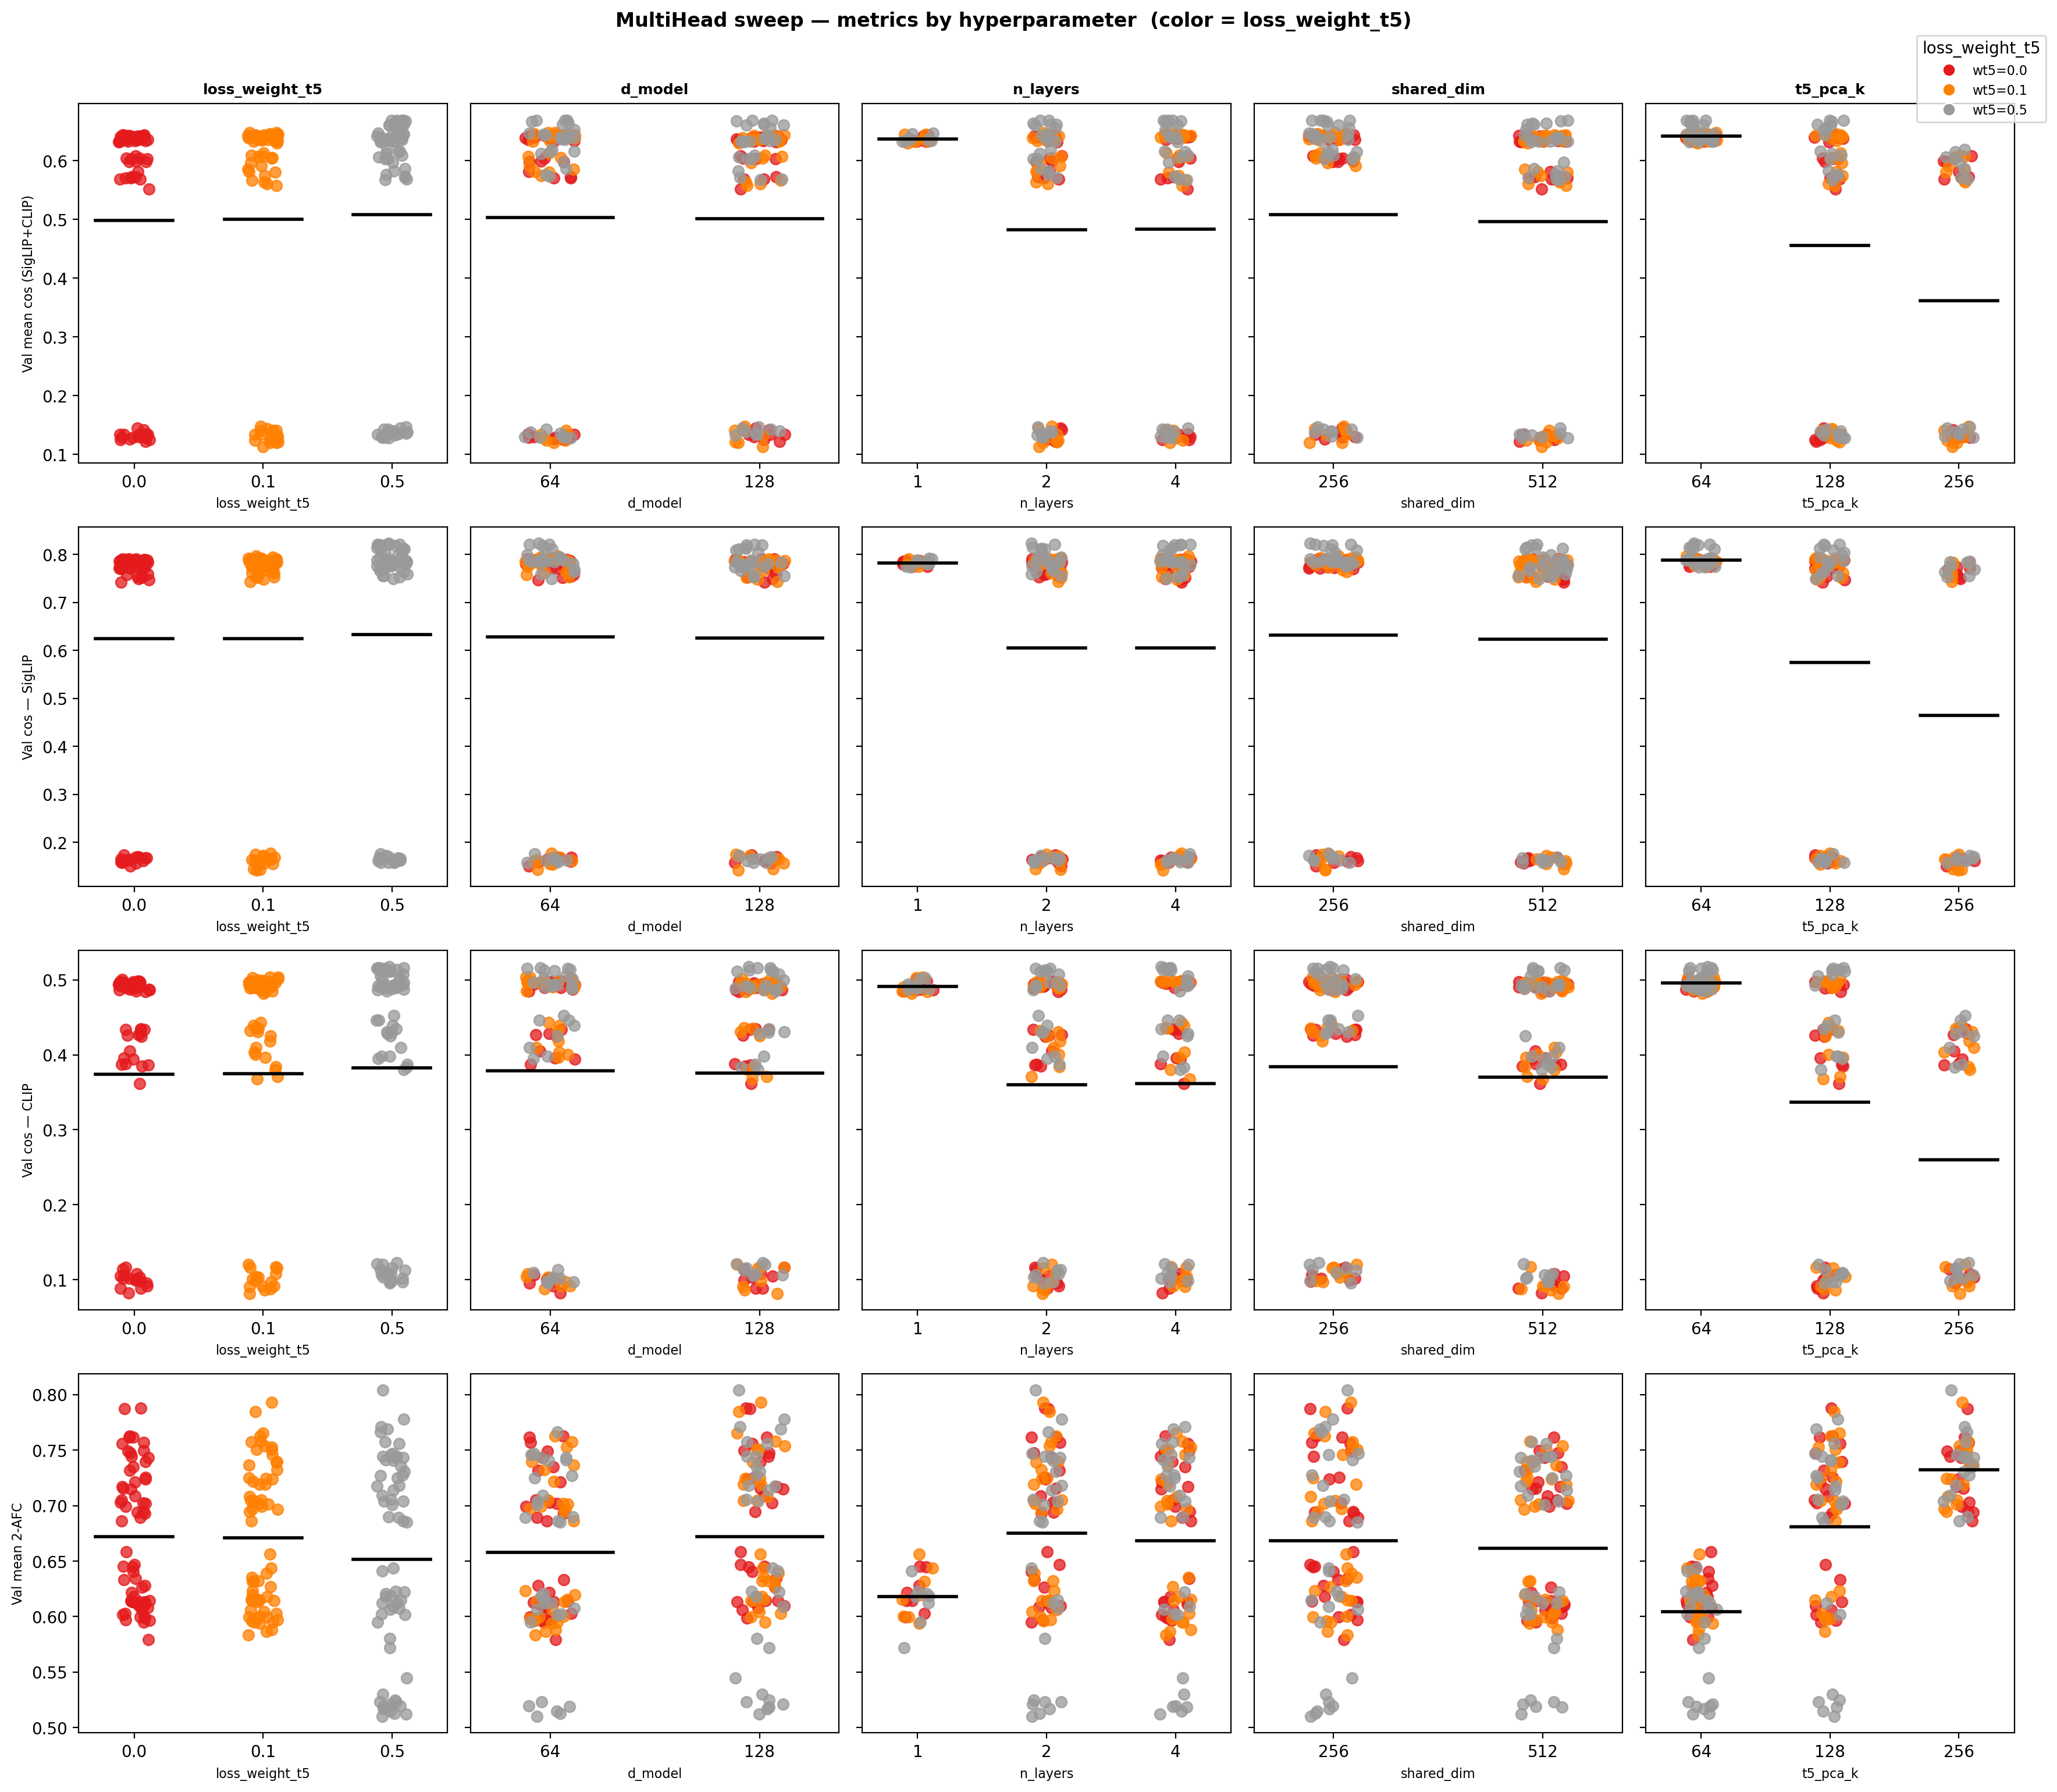

In [3]:
METRICS = [
    ("val_mean_cos",  "Val mean cos (SigLIP+CLIP)"),
    ("val_cos_siglip","Val cos — SigLIP"),
    ("val_cos_clip",  "Val cos — CLIP"),
    ("val_mean_2afc", "Val mean 2-AFC"),
]

fig, axes = plt.subplots(len(METRICS), len(SWEEP_AXES),
                         figsize=(3.5 * len(SWEEP_AXES), 3.8 * len(METRICS)),
                         sharey="row", squeeze=False)

rng = np.random.default_rng(0)

# color by loss_weight_t5
wt5_vals  = sorted(df["loss_weight_t5"].unique())
wt5_cmap  = plt.cm.get_cmap("Set1", len(wt5_vals))
wt5_color = {v: wt5_cmap(i) for i, v in enumerate(wt5_vals)}

for mi, (metric, ylabel) in enumerate(METRICS):
    if metric not in df.columns:
        continue
    for ai, axis_col in enumerate(SWEEP_AXES):
        ax = axes[mi, ai]
        levels = sorted(df[axis_col].unique())
        for lvl_i, lvl in enumerate(levels):
            sub = df[df[axis_col] == lvl]
            for wt5, grp in sub.groupby("loss_weight_t5"):
                vals = grp[metric].dropna().values
                if not len(vals):
                    continue
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=wt5_color[wt5], alpha=0.75, s=45,
                           label=f"wt5={wt5}" if ai == 0 and lvl_i == 0 else "_")
            all_vals = sub[metric].dropna().values
            if len(all_vals):
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [all_vals.mean(), all_vals.mean()], "k-", lw=2)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels])
        ax.set_xlabel(axis_col, fontsize=8)
        if ai == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if mi == 0:
            ax.set_title(axis_col, fontsize=9, fontweight="bold")

# legend for loss_weight_t5 colors
handles = [plt.Line2D([0],[0],marker='o',color='w',
           markerfacecolor=wt5_color[v],markersize=8,label=f"wt5={v}") for v in wt5_vals]
fig.legend(handles=handles, title="loss_weight_t5", loc="upper right",
           bbox_to_anchor=(1.01, 1), fontsize=8)
fig.suptitle("MultiHead sweep — metrics by hyperparameter  (color = loss_weight_t5)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Effect of loss_weight_t5 — key ablation

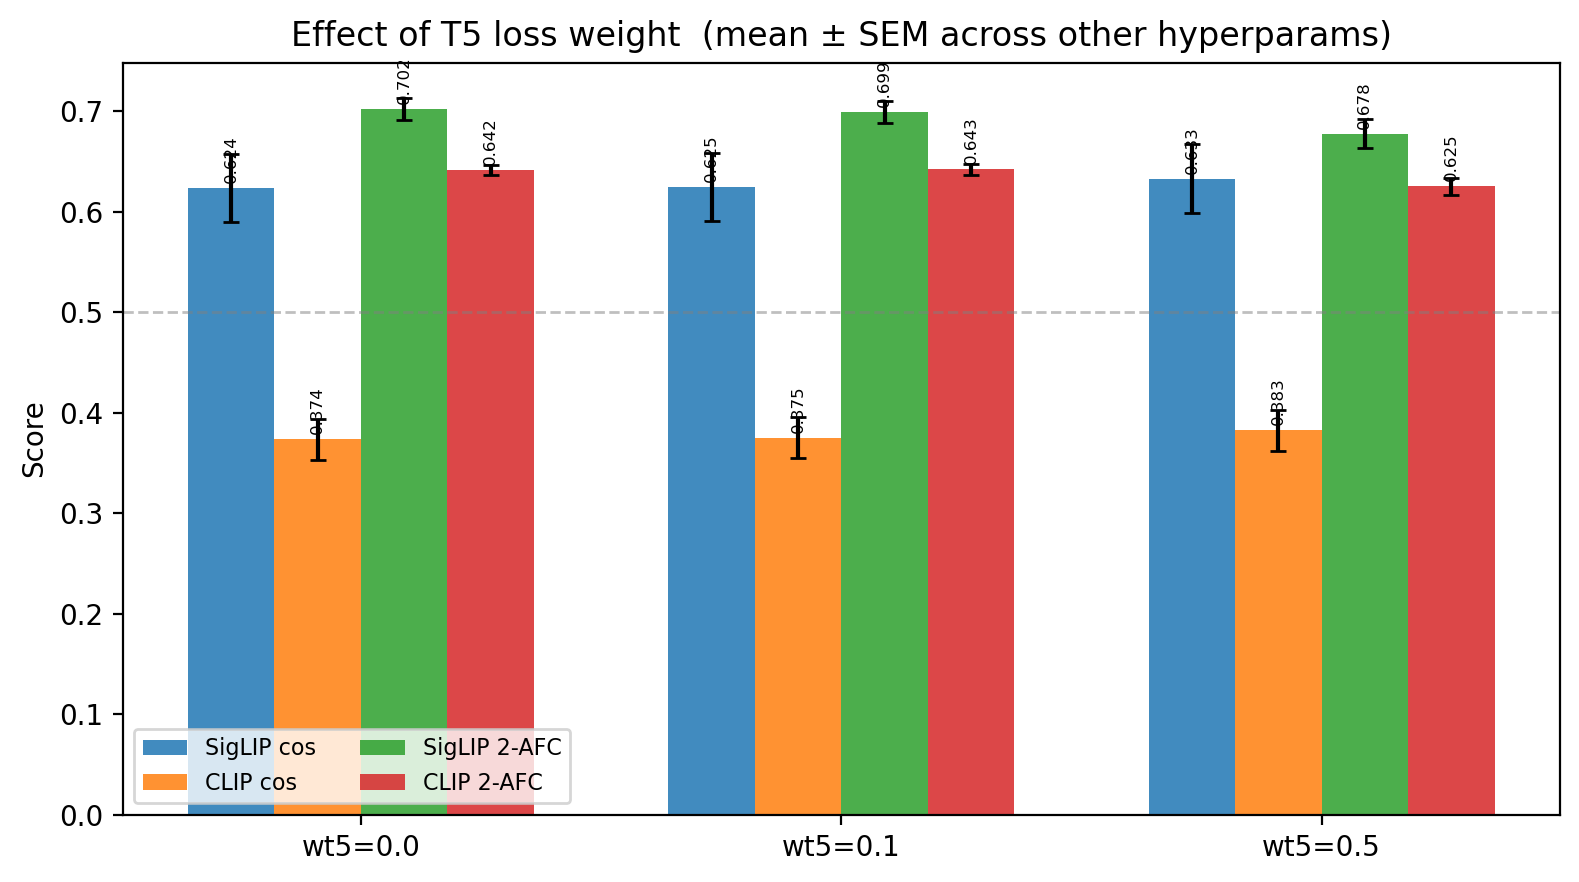

In [4]:
# Compare 0.0 (2-head) vs 0.1 vs 0.5 on SigLIP and CLIP cos/2afc
metrics_ab = [
    ("val_cos_siglip",  "SigLIP cos"),
    ("val_cos_clip",    "CLIP cos"),
    ("val_2afc_siglip", "SigLIP 2-AFC"),
    ("val_2afc_clip",   "CLIP 2-AFC"),
]
wt5_labels = sorted(df["loss_weight_t5"].unique())
x = np.arange(len(wt5_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 4.5))
offsets = np.linspace(-(len(metrics_ab)-1)/2, (len(metrics_ab)-1)/2, len(metrics_ab)) * width

for off, (metric, label) in zip(offsets, metrics_ab):
    means = [df[df["loss_weight_t5"] == w][metric].mean() for w in wt5_labels]
    sems  = [df[df["loss_weight_t5"] == w][metric].sem()  for w in wt5_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3, label=label, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f"wt5={v}" for v in wt5_labels])
ax.set_ylabel("Score")
ax.set_title("Effect of T5 loss weight  (mean ± SEM across other hyperparams)")
ax.legend(fontsize=8, ncol=2)
ax.axhline(0.5, color="grey", lw=1, ls="--", alpha=0.5, label="2-AFC chance")
plt.tight_layout()
plt.show()


## Val vs test generalisation

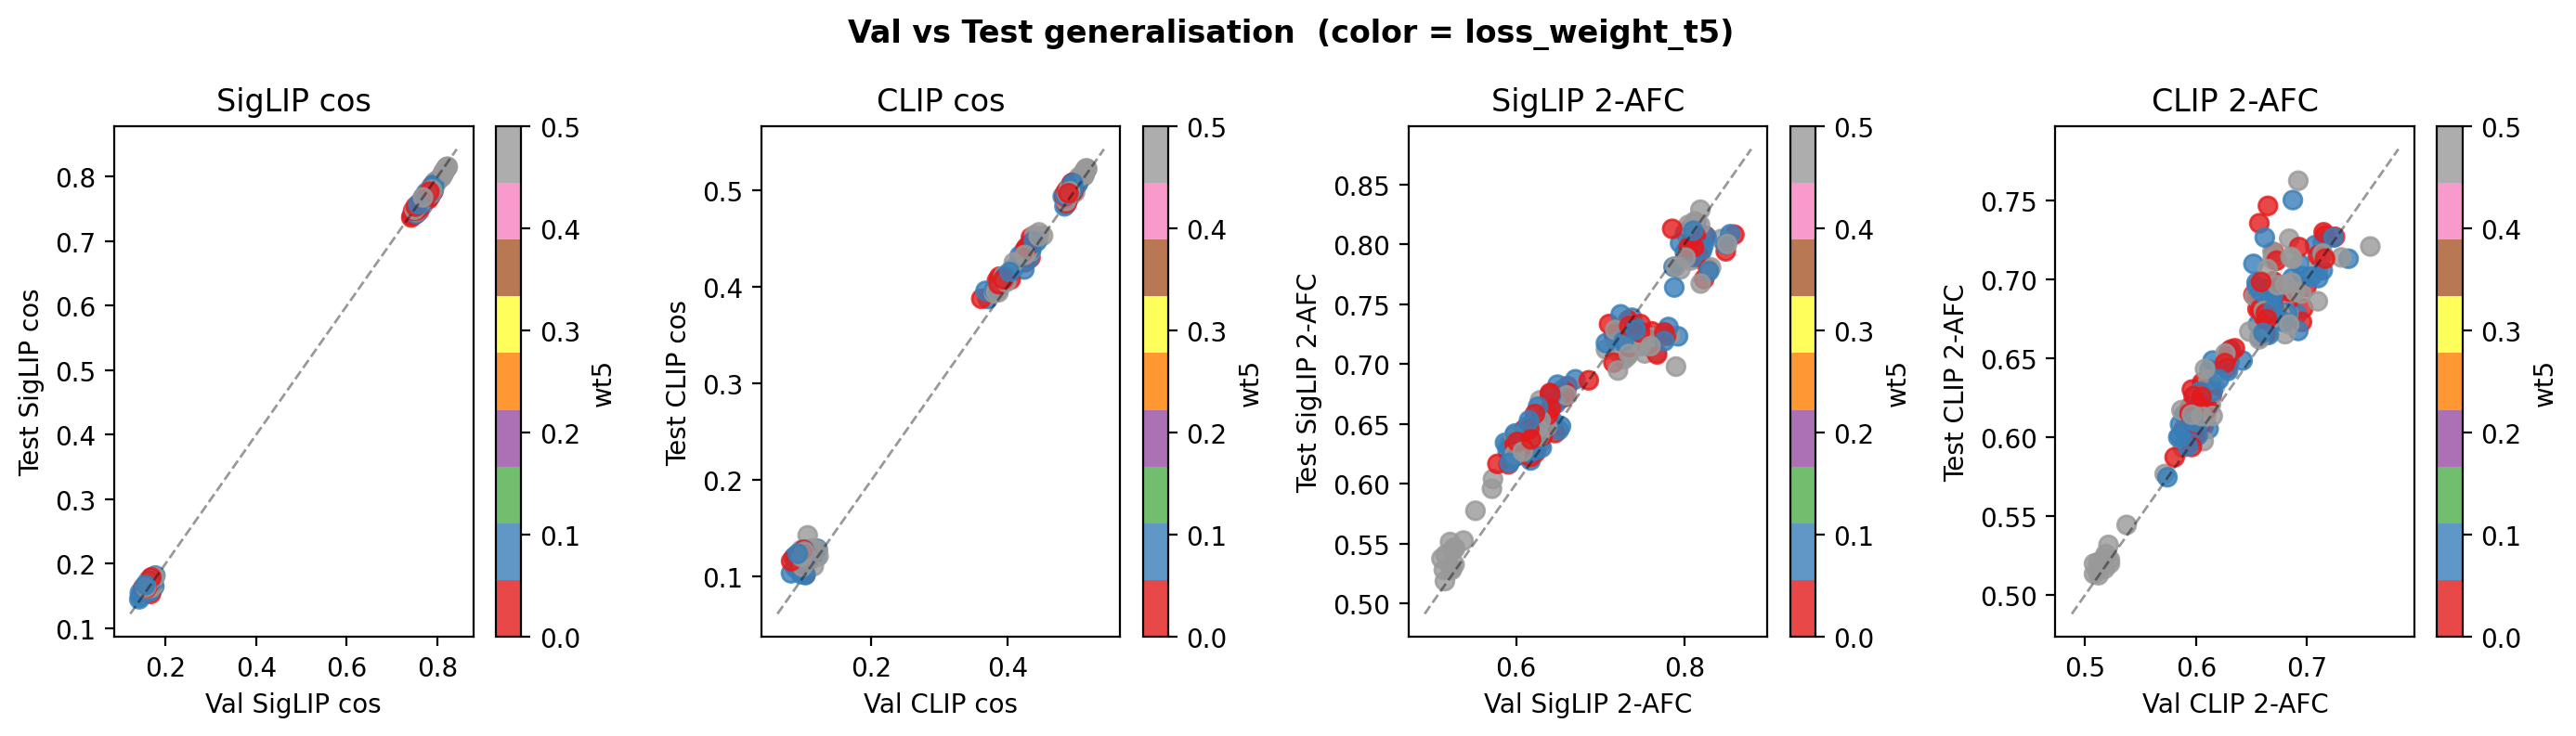

In [5]:
if has_test:
    pairs = [("val_cos_siglip","test_cos_siglip","SigLIP cos"),
             ("val_cos_clip",  "test_cos_clip",  "CLIP cos"),
             ("val_2afc_siglip","test_2afc_siglip","SigLIP 2-AFC"),
             ("val_2afc_clip",  "test_2afc_clip",  "CLIP 2-AFC")]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        sub = df.dropna(subset=[vcol, tcol])
        sc = ax.scatter(sub[vcol], sub[tcol],
                        c=sub["loss_weight_t5"], cmap="Set1",
                        vmin=sub["loss_weight_t5"].min(),
                        vmax=sub["loss_weight_t5"].max(),
                        s=50, alpha=0.8)
        lim = [min(sub[vcol].min(), sub[tcol].min()) - 0.02,
               max(sub[vcol].max(), sub[tcol].max()) + 0.02]
        ax.plot(lim, lim, "k--", lw=1, alpha=0.4)
        ax.set_xlabel(f"Val {title}")
        ax.set_ylabel(f"Test {title}")
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label="wt5")
    fig.suptitle("Val vs Test generalisation  (color = loss_weight_t5)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Test metrics not yet available — rerun once all jobs complete.")


## Top-10 runs by val mean cosine similarity

In [6]:
top_cols = [c for c in
    ["loss_weight_t5","d_model","n_layers","shared_dim","t5_pca_k",
     "epoch","val_mean_cos","val_cos_siglip","val_cos_clip",
     "val_mean_2afc","test_cos_siglip","test_cos_clip",
     "test_2afc_siglip","test_2afc_clip","path"]
    if c in df.columns]
display(df.sort_values("val_mean_cos", ascending=False)[top_cols].head(10).reset_index(drop=True))


,loss_weight_t5,d_model,n_layers,shared_dim,t5_pca_k,epoch,val_mean_cos,val_cos_siglip,val_cos_clip,val_mean_2afc,test_cos_siglip,test_cos_clip,test_2afc_siglip,test_2afc_clip,path
0,0.5,64,2,256,64,34,0.669170,0.822855,0.515485,0.512857,0.815646,0.520596,0.528163,0.515102,/home/yy3658/NeurObjectGen/checkpoints/multihe...
1,0.5,64,4,256,64,35,0.668574,0.821287,0.515861,0.519184,0.815093,0.520294,0.551429,0.523265,/home/yy3658/NeurObjectGen/checkpoints/multihe...
2,0.5,128,4,256,64,44,0.668401,0.819206,0.517595,0.544694,0.812989,0.522059,0.577551,0.544490,/home/yy3658/NeurObjectGen/checkpoints/multihe...
3,0.5,128,4,512,128,25,0.668387,0.820640,0.516135,0.518367,0.813740,0.522288,0.529388,0.518776,/home/yy3658/NeurObjectGen/checkpoints/multihe...
4,0.5,64,2,256,128,31,0.668306,0.820867,0.515744,0.509796,0.814872,0.521892,0.537551,0.520000,/home/yy3658/NeurObjectGen/checkpoints/multihe...
5,0.5,128,4,512,64,24,0.667992,0.819964,0.516020,0.511837,0.813228,0.520442,0.518776,0.513469,/home/yy3658/NeurObjectGen/checkpoints/multihe...
6,0.5,64,4,256,128,29,0.666328,0.819010,0.513646,0.514898,0.812440,0.519461,0.540816,0.517551,/home/yy3658/NeurObjectGen/checkpoints/multihe...
7,0.5,128,2,512,64,22,0.663800,0.814424,0.513176,0.520816,0.805730,0.516171,0.528163,0.516735,/home/yy3658/NeurObjectGen/checkpoints/multihe...
8,0.5,64,4,512,64,23,0.663753,0.814032,0.513473,0.518980,0.808437,0.516260,0.546531,0.520816,/home/yy3658/NeurObjectGen/checkpoints/multihe...
9,0.5,128,2,512,128,21,0.662132,0.812865,0.511399,0.524694,0.805073,0.515621,0.532653,0.522449,/home/yy3658/NeurObjectGen/checkpoints/multihe...


## Save best multihead config

In [7]:
import json
from config_const import CACHE_DIR

best_row = df[df['loss_weight_t5'] > 0].sort_values("val_mean_cos", ascending=False).iloc[0]
config = {
    "model": "multihead",
    "val_mean_cos":  float(best_row["val_mean_cos"]),
    "val_mean_2afc": float(best_row["val_mean_2afc"]),
    "checkpoint": best_row["path"],
    "d_model":    int(best_row["d_model"]),
    "n_heads":    int(best_row["n_heads"]),
    "n_layers":   int(best_row["n_layers"]),
    "shared_dim": int(best_row["shared_dim"]),
    "t5_pca_k":   int(best_row["t5_pca_k"]),
    "dropout":    float(best_row["dropout"]),
    "lr":         float(best_row["lr"]),
    "weight_decay":       float(best_row["weight_decay"]),
    "loss_weight_t5":     float(best_row["loss_weight_t5"]),
    "loss_weight_siglip": float(best_row["loss_weight_siglip"]),
    "loss_weight_clip":   float(best_row["loss_weight_clip"]),
}

out_path = CACHE_DIR / "best_multihead_config.json"
with open(out_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved to {out_path}")
print(f"  val_mean_cos={config['val_mean_cos']:.4f}  val_mean_2afc={config['val_mean_2afc']:.4f}")
print(f"  {config['checkpoint']}")


Saved to /home/yy3658/NeurObjectGen/cache/best_multihead_config.json
  val_mean_cos=0.6692  val_mean_2afc=0.5129
  /home/yy3658/NeurObjectGen/checkpoints/multihead/d64_nh4_nl2_sd256_k64_do0.1_lr0.0003_wd0.01_tn0.02_bs64_ws1.0_wc1.0_wt0.5_uw0.1/best.pt
